<a href="https://colab.research.google.com/github/arafatro/IntroToDS/blob/main/Practice%20Materials/Week%207/DS_Practice_Clustering_Classification_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Data Science
## Practice Session — Clustering, Classification & Regression
**Eötvös Loránd University (ELTE) · Faculty of Informatics**

---
**Instructor:** Arafat Md Easin  
**Weeks covered:** (Unsupervised learning: clustering basics) · (Supervised learning: classification workflow + evaluation) · (Supervised learning: regression + evaluation + regularization)

**Goal:** By the end of this session you will be able to:
- Apply **K-Means** and **DBSCAN** clustering, choose the right number of clusters, and evaluate results without labels
- Build a complete **classification workflow** — split, train, evaluate with accuracy, precision, recall, F1, ROC-AUC
- Understand the **confusion matrix** and what each cell means
- Train and evaluate **regression models**, understand MSE, MAE, R²
- Apply **Ridge, Lasso, and ElasticNet** regularization and see how they control model complexity

> **Tip:** Run each cell with `Shift + Enter` and read the comments carefully before moving on.  
> **Key principle:** A model is only as good as its evaluation — always measure on held-out data.

## Part 0 — Setup & Datasets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import (
    load_breast_cancer, load_wine, load_iris,
    load_diabetes, make_blobs, make_moons, make_regression
)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, KFold
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    mean_squared_error, mean_absolute_error, r2_score,
    classification_report, silhouette_score
)
from sklearn.cluster import KMeans, DBSCAN
from sklearn.linear_model import (
    LogisticRegression, LinearRegression,
    Ridge, Lasso, ElasticNet
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

RNG = np.random.default_rng(seed=42)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"]    = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

print("Setup complete.")

Setup complete.


In [2]:
# ── Load all datasets ─────────────────────────────────────────────────
# Clustering:      synthetic blobs, moons, iris
# Classification:  breast cancer (binary), wine (3-class)
# Regression:      diabetes, synthetic regression

X_blobs, y_blobs_true = make_blobs(n_samples=300, centers=4, cluster_std=0.9, random_state=42)
X_moons, y_moons_true = make_moons(n_samples=300, noise=0.08, random_state=42)

iris  = load_iris()
X_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
y_iris = pd.Series(iris.target, name="species")

bc = load_breast_cancer()
X_bc = pd.DataFrame(bc.data, columns=bc.feature_names)
y_bc = pd.Series(bc.target, name="target")

wine = load_wine()
X_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
y_wine = pd.Series(wine.target, name="cultivar")

diabetes = load_diabetes()
X_diab = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y_diab = pd.Series(diabetes.target, name="progression")

X_reg, y_reg = make_regression(n_samples=300, n_features=20, n_informative=10,
                                noise=25, random_state=42)

print("=== Clustering ===")
print(f"  Blobs: {X_blobs.shape}  |  Moons: {X_moons.shape}  |  Iris: {X_iris.shape}")
print()
print("=== Classification ===")
print(f"  Breast Cancer: {X_bc.shape}  classes: {dict(zip(bc.target_names, np.bincount(y_bc)))}")
print(f"  Wine:          {X_wine.shape}  classes: {dict(zip(wine.target_names, np.bincount(y_wine)))}")
print()
print("=== Regression ===")
print(f"  Diabetes: {X_diab.shape}  target range: [{y_diab.min():.0f}, {y_diab.max():.0f}]")
print(f"  Synthetic:  {X_reg.shape}")

=== Clustering ===
  Blobs: (300, 2)  |  Moons: (300, 2)  |  Iris: (150, 4)

=== Classification ===
  Breast Cancer: (569, 30)  classes: {np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}
  Wine:          (178, 13)  classes: {np.str_('class_0'): np.int64(59), np.str_('class_1'): np.int64(71), np.str_('class_2'): np.int64(48)}

=== Regression ===
  Diabetes: (442, 10)  target range: [25, 346]
  Synthetic:  (300, 20)


---
# Week 9 — Unsupervised Learning: Clustering Basics

Clustering groups data points so that points **within a cluster are similar** and points **across clusters are different** — without using any labels.

Why unsupervised?
- Labels are expensive or unavailable.
- We want to discover hidden structure: customer segments, gene expression groups, anomaly regions.

| Algorithm | Idea | Strengths | Weaknesses |
|---|---|---|---|
| **K-Means** | Assign points to k centroids; iterate until stable | Fast, scalable, well-understood | Needs k in advance; assumes spherical clusters |
| **DBSCAN** | Clusters = dense regions; sparse points = noise | Finds arbitrary shapes; detects outliers | Two sensitive hyperparameters (eps, min_samples) |

> **Key insight:** Without labels, we cannot use accuracy. We use **inertia** (within-cluster sum of squares), **silhouette score**, and visual inspection instead.

## Part 1 — K-Means Clustering

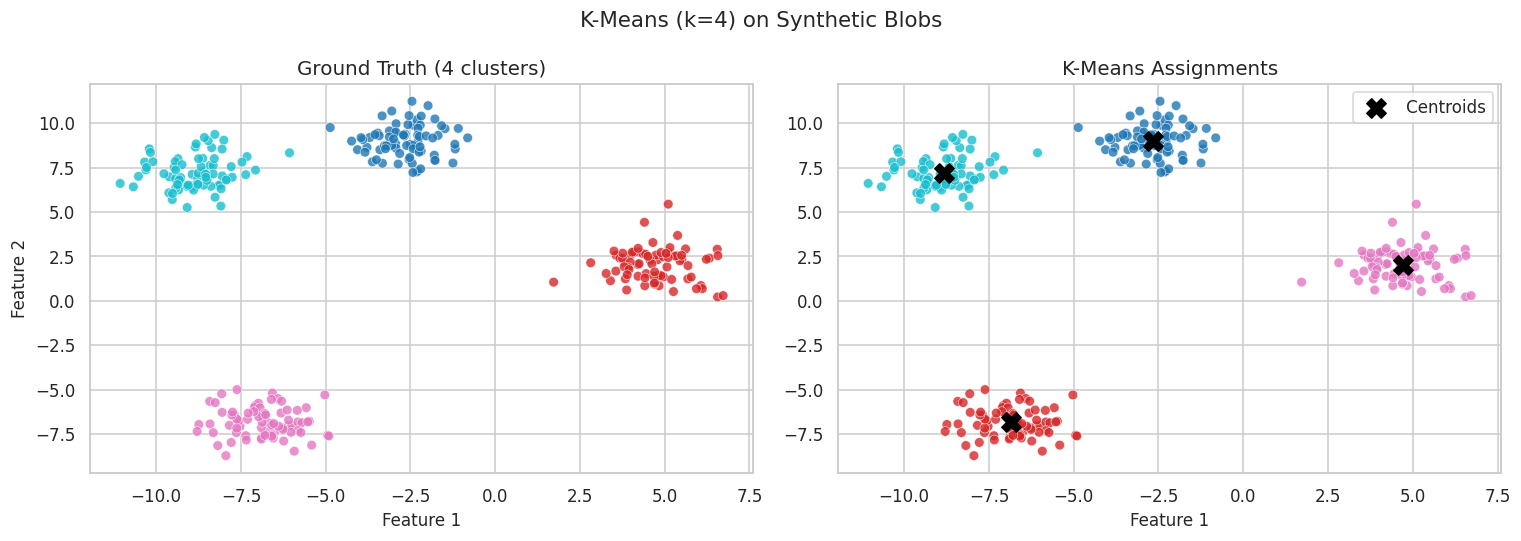

Inertia (within-cluster SSE): 458.8
Cluster sizes: {np.int32(0): np.int64(75), np.int32(1): np.int64(75), np.int32(2): np.int64(75), np.int32(3): np.int64(75)}


In [3]:
# ── 1.1  K-Means on synthetic blobs ──────────────────────────────────
# K-Means alternates between two steps until assignments stop changing:
#   E-step: assign each point to its nearest centroid
#   M-step: recompute centroids as the mean of all assigned points
#
# We know the true answer is 4 clusters — let's see if K-Means recovers it.

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_km = kmeans.fit_predict(X_blobs)

scatter_kw = dict(s=40, alpha=0.8, edgecolors="white", linewidth=0.4)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("K-Means (k=4) on Synthetic Blobs", fontsize=14)

axes[0].scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_blobs_true, cmap="tab10", **scatter_kw)
axes[0].set_title("Ground Truth (4 clusters)")
axes[0].set_xlabel("Feature 1"); axes[0].set_ylabel("Feature 2")

axes[1].scatter(X_blobs[:, 0], X_blobs[:, 1], c=labels_km, cmap="tab10", **scatter_kw)
axes[1].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                c="black", marker="X", s=160, zorder=5, label="Centroids")
axes[1].set_title("K-Means Assignments")
axes[1].set_xlabel("Feature 1")
axes[1].legend()

plt.tight_layout(); plt.show()

print(f"Inertia (within-cluster SSE): {kmeans.inertia_:.1f}")
print(f"Cluster sizes: {dict(zip(*np.unique(labels_km, return_counts=True)))}")

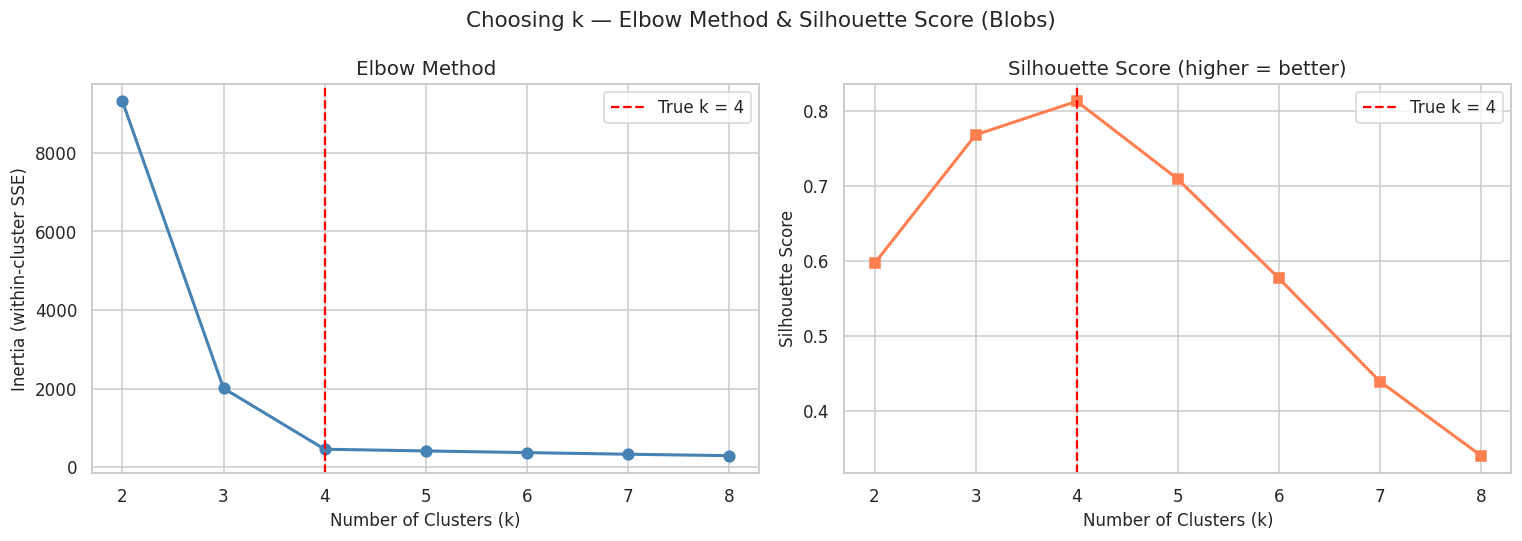

Best k by silhouette: 4  (score = 0.812)


In [4]:
# ── 1.2  Choosing k: Elbow Method and Silhouette Score ───────────────
# Elbow method: plot inertia vs k — look for the point of diminishing returns.
# Silhouette score: how well each point fits its own cluster vs the next nearest.
#   Range [-1, 1]. Higher is better. 0 means on the boundary between clusters.

k_range = range(2, 9)
inertias    = []
silhouettes = []

for k in k_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_blobs)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_blobs, lbl))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Choosing k — Elbow Method & Silhouette Score (Blobs)", fontsize=14)

axes[0].plot(list(k_range), inertias, marker="o", color="steelblue", linewidth=2, markersize=7)
axes[0].axvline(4, color="red", linestyle="--", linewidth=1.5, label="True k = 4")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia (within-cluster SSE)")
axes[0].set_title("Elbow Method")
axes[0].legend()

axes[1].plot(list(k_range), silhouettes, marker="s", color="coral", linewidth=2, markersize=7)
axes[1].axvline(4, color="red", linestyle="--", linewidth=1.5, label="True k = 4")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score (higher = better)")
axes[1].legend()

plt.tight_layout(); plt.show()

best_k = list(k_range)[np.argmax(silhouettes)]
print(f"Best k by silhouette: {best_k}  (score = {max(silhouettes):.3f})")

## Part 2 — DBSCAN: Density-Based Clustering

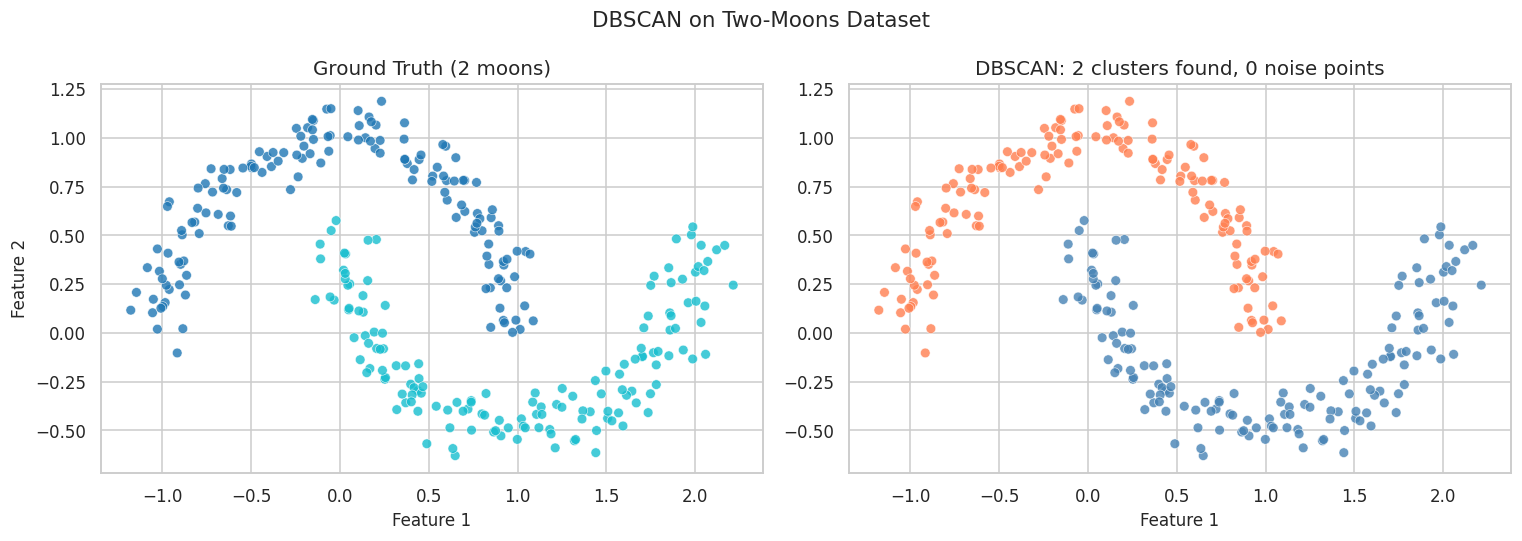

Clusters: 2  |  Noise points: 0


In [5]:
# ── 2.1  DBSCAN on non-spherical data ────────────────────────────────
# DBSCAN defines clusters as dense regions separated by sparse areas.
# Two hyperparameters:
#   eps         — neighbourhood radius. Points within eps of a core point belong to it.
#   min_samples — minimum points within eps to be called a core point.
#
# Points unreachable from any core point are labelled NOISE (label = -1).
# DBSCAN does NOT require specifying k beforehand.

dbscan = DBSCAN(eps=0.3, min_samples=10)
labels_db = dbscan.fit_predict(X_moons)

n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise    = np.sum(labels_db == -1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("DBSCAN on Two-Moons Dataset", fontsize=14)

axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons_true, cmap="tab10", **scatter_kw)
axes[0].set_title("Ground Truth (2 moons)")
axes[0].set_xlabel("Feature 1"); axes[0].set_ylabel("Feature 2")

colors_db = ["steelblue" if l == 0 else "coral" if l == 1 else "grey" for l in labels_db]
axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=colors_db, **scatter_kw)
axes[1].set_title(f"DBSCAN: {n_clusters} clusters found, {n_noise} noise points")
axes[1].set_xlabel("Feature 1")

plt.tight_layout(); plt.show()
print(f"Clusters: {n_clusters}  |  Noise points: {n_noise}")

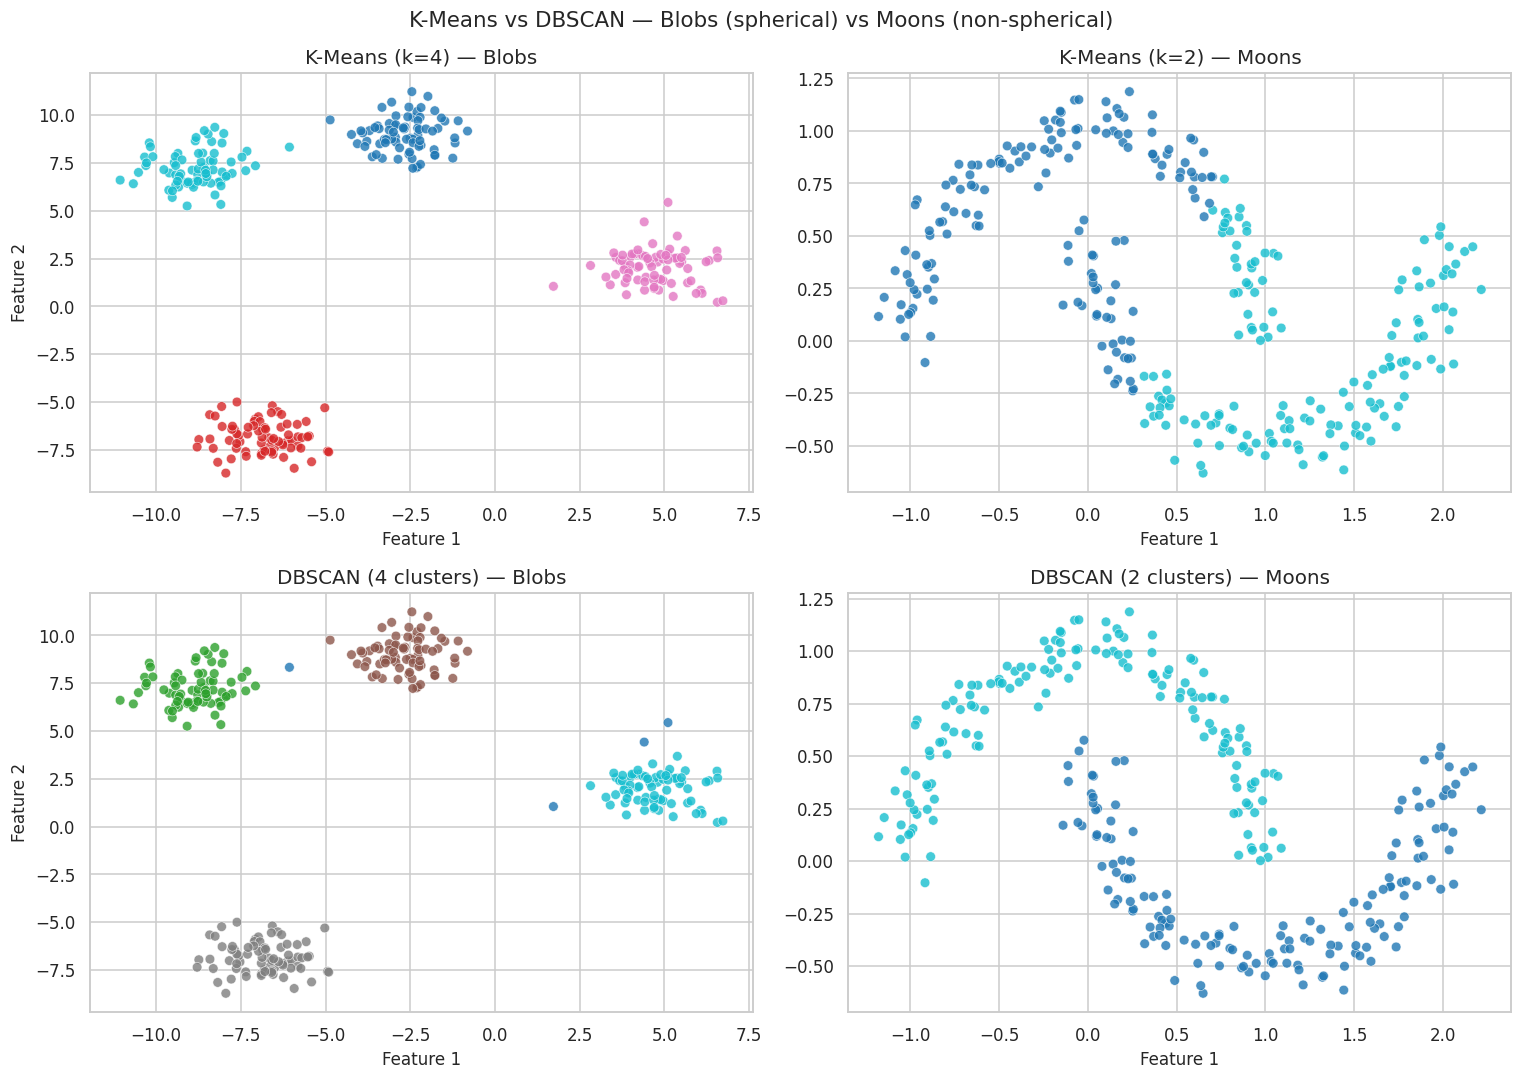

K-Means handles the spherical blobs well but fails on the crescent moons.
DBSCAN recovers both cluster shapes correctly.


In [6]:
# ── 2.2  K-Means vs DBSCAN on both datasets ──────────────────────────
# K-Means assumes spherical clusters — it struggles on irregular shapes.
# DBSCAN handles arbitrary shapes and detects noise naturally.

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("K-Means vs DBSCAN — Blobs (spherical) vs Moons (non-spherical)", fontsize=14)

datasets = [
    ("Blobs", X_blobs, 4, DBSCAN(eps=1.0, min_samples=8)),
    ("Moons", X_moons, 2, DBSCAN(eps=0.3, min_samples=10)),
]

for col, (name, X, k, db) in enumerate(datasets):
    km_lbl = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X)
    axes[0, col].scatter(X[:, 0], X[:, 1], c=km_lbl, cmap="tab10", **scatter_kw)
    axes[0, col].set_title(f"K-Means (k={k}) — {name}")
    axes[0, col].set_xlabel("Feature 1")
    if col == 0: axes[0, col].set_ylabel("Feature 2")

    db_lbl = db.fit_predict(X)
    n_cl   = len(set(db_lbl)) - (1 if -1 in db_lbl else 0)
    axes[1, col].scatter(X[:, 0], X[:, 1], c=db_lbl, cmap="tab10", **scatter_kw)
    axes[1, col].set_title(f"DBSCAN ({n_cl} clusters) — {name}")
    axes[1, col].set_xlabel("Feature 1")
    if col == 0: axes[1, col].set_ylabel("Feature 2")

plt.tight_layout(); plt.show()

print("K-Means handles the spherical blobs well but fails on the crescent moons.")
print("DBSCAN recovers both cluster shapes correctly.")

### Exercise 1 — Clustering the Iris Dataset (Week 9)

The Iris dataset has 3 known species — but pretend you don't know that. Use only the **first two features** (`sepal length (cm)` and `sepal width (cm)`) so you can visualise in 2D.

1. Scale both features with `StandardScaler`.
2. Apply **K-Means** for k = 2, 3, and 4. Plot the clusters side by side (1 row, 3 panels). Mark centroids with an ✕.
3. Plot the **Elbow curve** and **Silhouette score** for k = 2 … 7. Which k does each metric suggest?
4. Apply **DBSCAN** with `eps=0.5, min_samples=5`. How many clusters are found? How many noise points?
5. In a text cell: which method and k would you choose for this data, and why?

In [ ]:
# Your code here


```
# Your answer here
```

---
# Supervised Learning: Classification Workflow + Evaluation

Classification maps input features to a **discrete class label**.

## The standard workflow
1. Split into train / test (hold-out set — never seen during training)
2. (Optional) Scale features
3. Train a model on the training set
4. Evaluate on the test set using appropriate metrics
5. Compare models with cross-validation on the training set, then report final performance on test once

> **Golden rule:** Never tune or evaluate on data you trained on. This causes *data leakage* and artificially inflated results.

## Part 3 — Train/Test Split & Baseline

In [7]:
# ── 3.1  Split, scale, and establish a baseline ───────────────────────
# Breast Cancer dataset: 30 features, binary target (0=malignant, 1=benign).
# stratify=y_bc ensures both splits have the same class proportions.

X_train, X_test, y_train, y_test = train_test_split(
    X_bc, y_bc, test_size=0.2, random_state=42, stratify=y_bc
)

scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)   # fit ONLY on train
X_test_sc   = scaler.transform(X_test)        # transform test with the same params

# Baseline: always predict the majority class — any useful model must beat this.
majority_class = y_train.mode()[0]
y_dummy        = np.full(len(y_test), majority_class)
baseline_acc   = accuracy_score(y_test, y_dummy)

print(f"Train: {X_train.shape[0]} samples  |  Test: {X_test.shape[0]} samples")
print(f"Class balance (train): {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Class balance (test):  {dict(zip(*np.unique(y_test, return_counts=True)))}")
print(f"\nBaseline accuracy (always predict class {majority_class}): {baseline_acc:.4f}")
print("Any model that fails to beat this is not learning anything useful.")

Train: 455 samples  |  Test: 114 samples
Class balance (train): {np.int64(0): np.int64(170), np.int64(1): np.int64(285)}
Class balance (test):  {np.int64(0): np.int64(42), np.int64(1): np.int64(72)}

Baseline accuracy (always predict class 1): 0.6316
Any model that fails to beat this is not learning anything useful.


## Part 4 — Classification Metrics

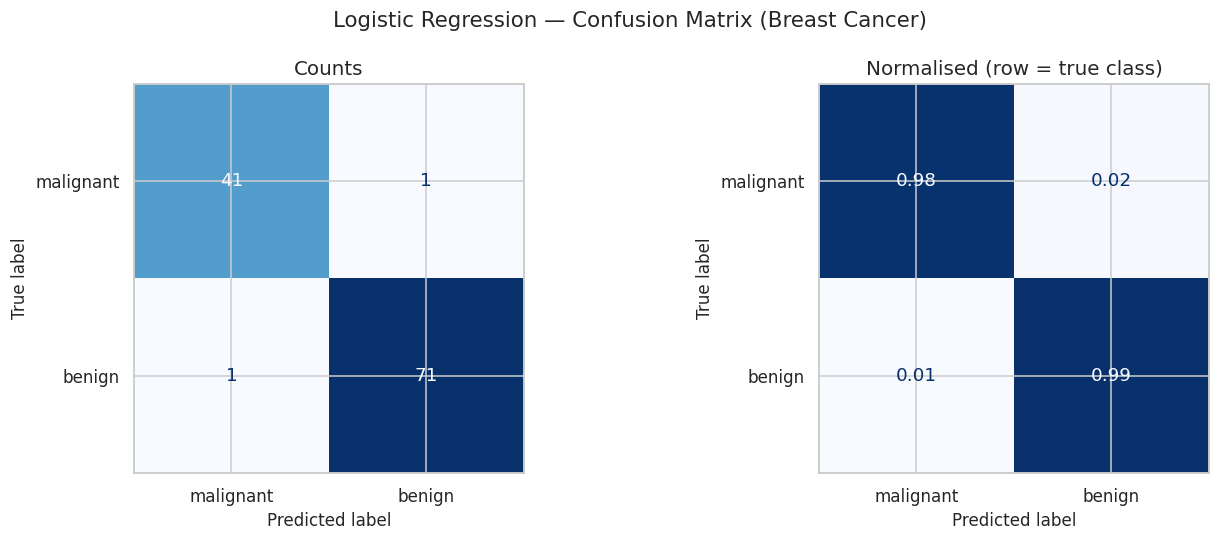

TN=41  FP=1  FN=1  TP=71

Accuracy:  0.9825
Precision: 0.9861  (of predicted benign, how many were right?)
Recall:    0.9861  (of actual benign, how many did we catch?)
F1-Score:  0.9861


In [8]:
# ── 4.1  Confusion Matrix and core metrics ────────────────────────────
# For binary classification:
#
#                  Predicted
#                  0 (Neg)   1 (Pos)
# Actual  0 (Neg) |   TN   |   FP  |   False Positive = Type I error
#         1 (Pos) |   FN   |   TP  |   False Negative = Type II error
#
# Accuracy  = (TP + TN) / total        — overall correctness
# Precision = TP / (TP + FP)           — of all predicted positives, how many were right?
# Recall    = TP / (TP + FN)           — of all actual positives, how many did we catch?
# F1        = 2 * P * R / (P + R)      — harmonic mean of Precision and Recall

log_reg = LogisticRegression(max_iter=5000, random_state=42)
log_reg.fit(X_train_sc, y_train)
y_pred = log_reg.predict(X_test_sc)

cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Logistic Regression — Confusion Matrix (Breast Cancer)", fontsize=14)

ConfusionMatrixDisplay(cm, display_labels=bc.target_names).plot(
    ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Counts")

cm_norm = confusion_matrix(y_test, y_pred, normalize="true")
ConfusionMatrixDisplay(cm_norm, display_labels=bc.target_names).plot(
    ax=axes[1], colorbar=False, cmap="Blues", values_format=".2f")
axes[1].set_title("Normalised (row = true class)")

plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")
print()
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}  (of predicted benign, how many were right?)")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}  (of actual benign, how many did we catch?)")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")

In [9]:
# ── 4.2  When does the metric choice matter? ─────────────────────────
# In cancer screening: a False Negative (missing cancer) is far more dangerous
# than a False Positive (unnecessary follow-up).
# → Prioritise RECALL for the malignant class (label 0 in this dataset).
#
# In spam filtering: a False Positive (blocking real email) may be worse.
# → Prioritise PRECISION.
#
# Accuracy can be misleading on imbalanced datasets — a 95% accurate model
# that simply predicts the majority class is often useless.

print("Clinical interpretation:")
print(f"  FN = {fn} malignant tumours classified as benign  →  MISSED CANCER (dangerous)")
print(f"  FP = {fp} benign cases classified as malignant    →  unnecessary follow-up (costly but safer)")
print()
print("The choice of metric should reflect the real-world cost of each error type.")
print()
print(classification_report(y_test, y_pred, target_names=bc.target_names))

Clinical interpretation:
  FN = 1 malignant tumours classified as benign  →  MISSED CANCER (dangerous)
  FP = 1 benign cases classified as malignant    →  unnecessary follow-up (costly but safer)

The choice of metric should reflect the real-world cost of each error type.

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



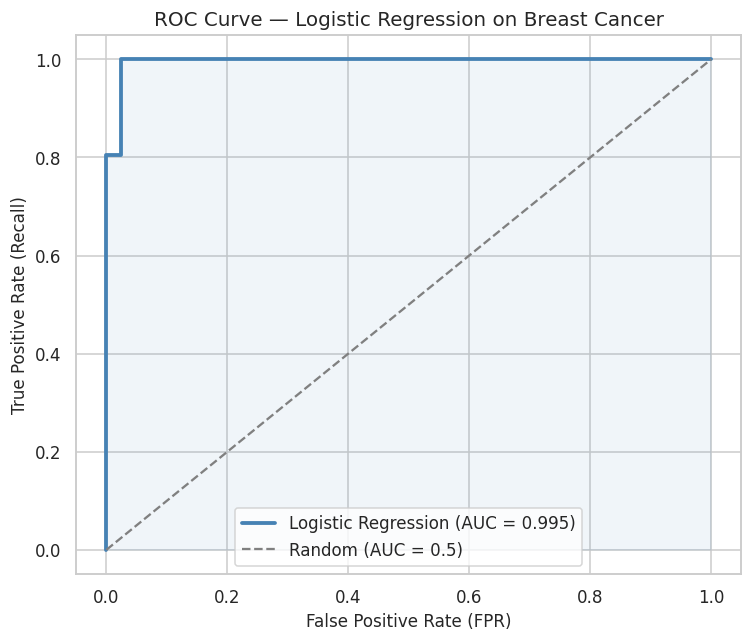

AUC = 0.9954  — the model separates the two classes very well.


In [10]:
# ── 4.3  ROC Curve and AUC ────────────────────────────────────────────
# The ROC curve shows the TPR vs FPR trade-off at every classification threshold.
# AUC (Area Under the Curve):
#   1.0 = perfect classifier
#   0.5 = no better than random guessing
# AUC is threshold-independent and robust to class imbalance.

y_prob = log_reg.predict_proba(X_test_sc)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color="steelblue", linewidth=2.5,
        label=f"Logistic Regression (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], color="grey", linestyle="--", linewidth=1.5, label="Random (AUC = 0.5)")
ax.fill_between(fpr, tpr, alpha=0.08, color="steelblue")
ax.set_xlabel("False Positive Rate (FPR)")
ax.set_ylabel("True Positive Rate (Recall)")
ax.set_title("ROC Curve — Logistic Regression on Breast Cancer")
ax.legend()
plt.tight_layout(); plt.show()

print(f"AUC = {auc:.4f}  — the model separates the two classes very well.")

## Part 5 — Comparing Multiple Classifiers

In [11]:
# ── 5.1  Five-fold stratified cross-validation across classifiers ─────
# Cross-validation on the TRAINING set tells us which model generalises best
# without touching the test set.
# We evaluate the winner on the test set only once at the end.

classifiers = {
    "Logistic Regression":  Pipeline([("sc", StandardScaler()),
                                      ("clf", LogisticRegression(max_iter=5000, random_state=42))]),
    "KNN (k=7)":            Pipeline([("sc", StandardScaler()),
                                      ("clf", KNeighborsClassifier(n_neighbors=7))]),
    "Random Forest":        RandomForestClassifier(n_estimators=200, random_state=42),
}

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, clf in classifiers.items():
    acc = cross_val_score(clf, X_bc, y_bc, cv=cv5, scoring="accuracy")
    f1  = cross_val_score(clf, X_bc, y_bc, cv=cv5, scoring="f1")
    cv_results[name] = {"accuracy": acc, "f1": f1}
    print(f"{name:25s}  acc={acc.mean():.4f}±{acc.std():.4f}  f1={f1.mean():.4f}±{f1.std():.4f}")

Logistic Regression        acc=0.9737±0.0166  f1=0.9794±0.0127
KNN (k=7)                  acc=0.9649±0.0184  f1=0.9728±0.0139
Random Forest              acc=0.9543±0.0102  f1=0.9637±0.0080


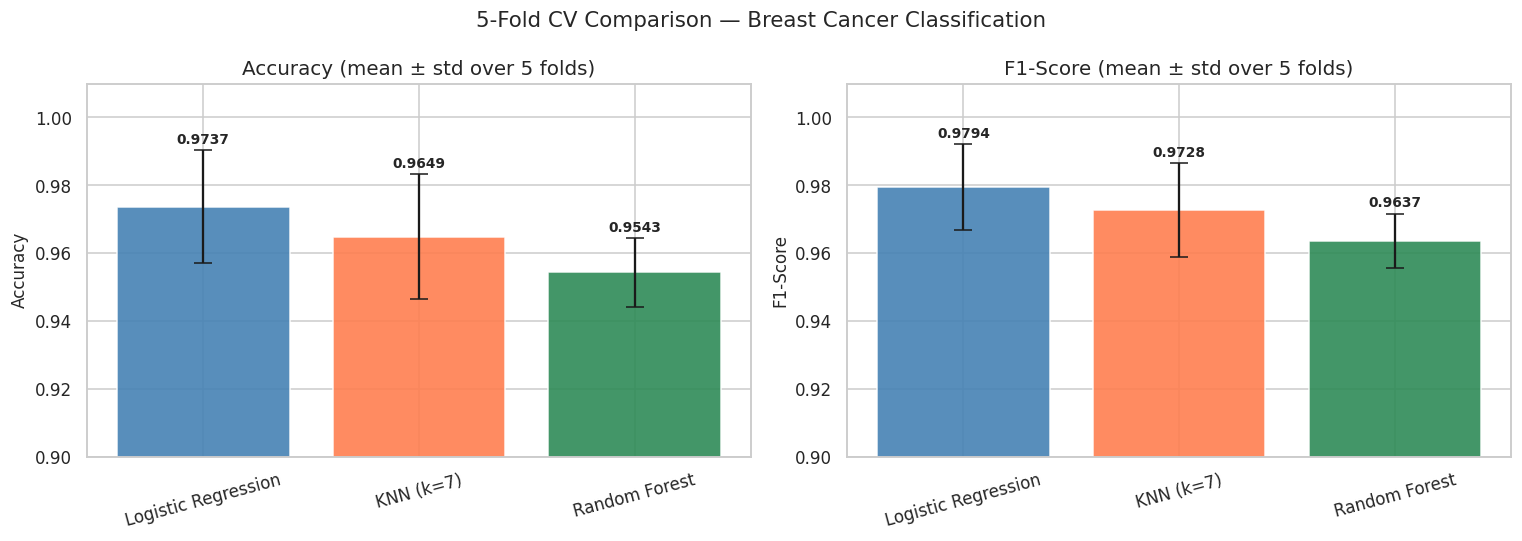

Best model by CV F1: Logistic Regression  (0.9794)


In [12]:
# ── 5.2  Visual comparison ────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("5-Fold CV Comparison — Breast Cancer Classification", fontsize=14)

for ax, metric, title in zip(axes, ["accuracy", "f1"], ["Accuracy", "F1-Score"]):
    names = list(cv_results.keys())
    means = [cv_results[n][metric].mean() for n in names]
    stds  = [cv_results[n][metric].std()  for n in names]
    colors = ["steelblue", "coral", "seagreen"]

    bars = ax.bar(names, means, yerr=stds, capsize=6,
                  color=colors, edgecolor="white", alpha=0.9)
    ax.set_ylim(0.90, 1.01)
    ax.set_ylabel(title)
    ax.set_title(f"{title} (mean ± std over 5 folds)")
    ax.tick_params(axis="x", rotation=15)

    for bar, m, s in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + s + 0.001,
                f"{m:.4f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout(); plt.show()
best = max(cv_results, key=lambda k: cv_results[k]["f1"].mean())
print(f"Best model by CV F1: {best}  ({cv_results[best]['f1'].mean():.4f})")

## Part 6 — Multi-Class Classification (Wine Dataset)

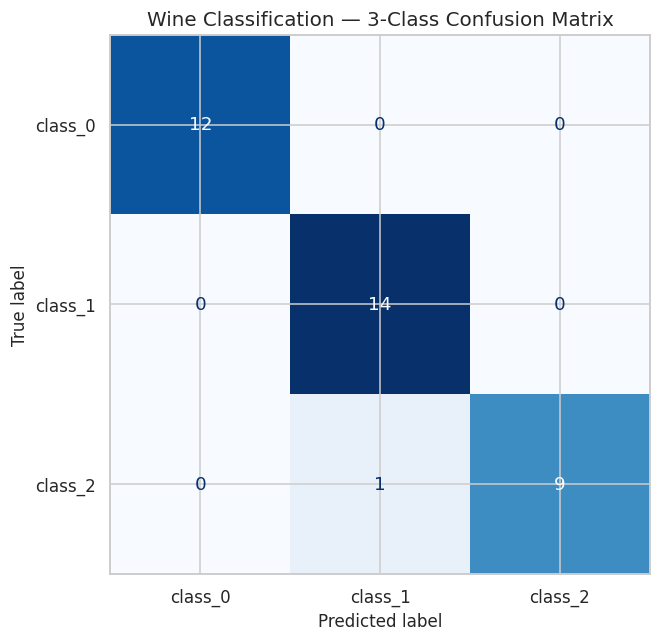

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



In [13]:
# ── 6.1  3-class confusion matrix and classification report ──────────
# For 3+ classes: macro-averaging computes each metric per class then averages,
# treating all classes equally regardless of frequency.
# Weighted averaging weights by the number of true samples in each class.

X_w_train, X_w_test, y_w_train, y_w_test = train_test_split(
    X_wine, y_wine, test_size=0.2, random_state=42, stratify=y_wine
)

pipe_wine = Pipeline([
    ("sc",  StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000, random_state=42))
])
pipe_wine.fit(X_w_train, y_w_train)
y_w_pred = pipe_wine.predict(X_w_test)

cm_wine = confusion_matrix(y_w_test, y_w_pred)

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm_wine, display_labels=wine.target_names).plot(
    ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Wine Classification — 3-Class Confusion Matrix")
plt.tight_layout(); plt.show()

print(classification_report(y_w_test, y_w_pred, target_names=wine.target_names))

### Exercise 2 — Full Classification Workflow (Week 10)

Using the **Wine dataset** (`X_wine`, `y_wine`, 3 classes):

1. Split into 80% train / 20% test (stratified, `random_state=42`).
2. Train **three classifiers** (your choice — e.g., Logistic Regression, KNN, Random Forest). Use a `Pipeline` with `StandardScaler` for any model that needs it.
3. For each classifier, report: **accuracy**, **macro F1**, and the **3-class confusion matrix**.
4. Use **5-fold stratified CV** on the training set to compare all three by macro F1. Plot results as a bar chart with error bars.
5. Pick the best model and explain in a text cell **why** you chose it and what trade-offs the others have.
6. Report the final test-set performance of your best model (evaluated only once).

In [ ]:
# Your code here


```
# Your answer here
```

---
# Supervised Learning: Regression + Evaluation + Regularization

Regression predicts a **continuous numeric output** (e.g., house price, patient's disease progression).

## Regression metrics

| Metric | Formula | Interpretation |
|---|---|---|
| **MSE** | $\frac{1}{n}\sum(y_i - \hat y_i)^2$ | Penalises large errors heavily (squared units) |
| **RMSE** | $\sqrt{\text{MSE}}$ | Same units as the target — most interpretable |
| **MAE** | $\frac{1}{n}\sum|y_i - \hat y_i|$ | Robust to outliers; average absolute error |
| **R²** | $1 - \frac{\sum(y_i - \hat y_i)^2}{\sum(y_i - \bar y)^2}$ | Proportion of variance explained. 1 = perfect, 0 = baseline mean model |

> **R² = 0** means the model does no better than simply predicting the mean.  
> **R² < 0** means the model is *worse* than predicting the mean.

## Part 7 — Linear Regression & Residual Analysis

In [14]:
# ── 7.1  Linear Regression on the Diabetes Dataset ───────────────────
# Target: disease progression one year after baseline.
# 10 features: age, sex, bmi, blood pressure, and 6 serum measurements.

X_d_train, X_d_test, y_d_train, y_d_test = train_test_split(
    X_diab, y_diab, test_size=0.2, random_state=42
)

lr = LinearRegression()
lr.fit(X_d_train, y_d_train)
y_d_pred = lr.predict(X_d_test)

mse = mean_squared_error(y_d_test, y_d_pred)
mae = mean_absolute_error(y_d_test, y_d_pred)
r2  = r2_score(y_d_test, y_d_pred)

print("Linear Regression — Diabetes Dataset")
print(f"  MSE  = {mse:.2f}")
print(f"  RMSE = {np.sqrt(mse):.2f}  (same units as target: disease progression score)")
print(f"  MAE  = {mae:.2f}")
print(f"  R²   = {r2:.4f}  → model explains {r2*100:.1f}% of the variance in progression")

Linear Regression — Diabetes Dataset
  MSE  = 2900.19
  RMSE = 53.85  (same units as target: disease progression score)
  MAE  = 42.79
  R²   = 0.4526  → model explains 45.3% of the variance in progression


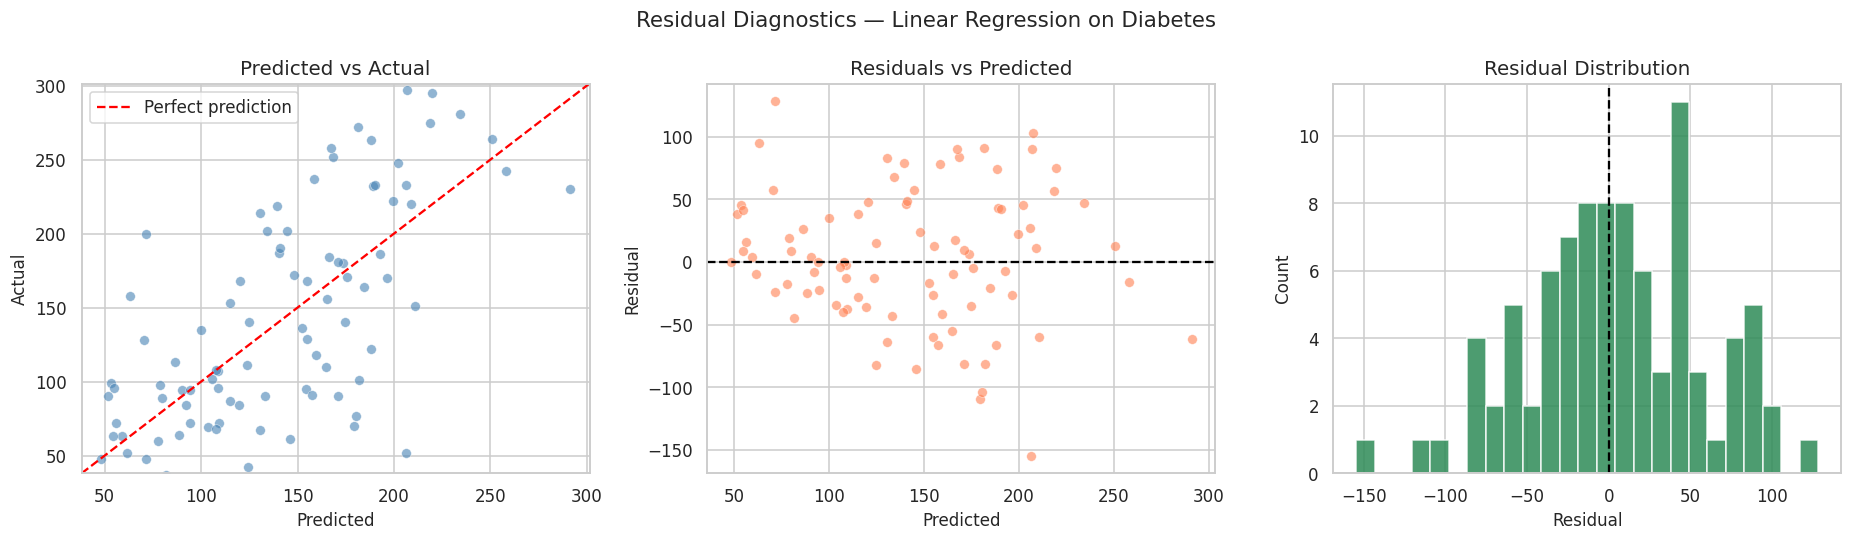

Mean residual (should be ≈ 0): 3.9128
Std of residuals:              53.71


In [15]:
# ── 7.2  Residual plots — diagnosing model fit ───────────────────────
# Residuals = y_true - y_pred
# A well-fitting linear model should have residuals:
#   - scattered randomly around 0 (no systematic pattern)
#   - roughly normally distributed
# Patterns in residuals → the model is missing non-linearity or other structure.

residuals = y_d_test.values - y_d_pred

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Residual Diagnostics — Linear Regression on Diabetes", fontsize=14)

# Predicted vs Actual
axes[0].scatter(y_d_pred, y_d_test, alpha=0.6, color="steelblue",
                edgecolors="white", linewidth=0.4, s=40)
lim = (y_d_pred.min() - 10, y_d_pred.max() + 10)
axes[0].plot(lim, lim, "--", color="red", linewidth=1.5, label="Perfect prediction")
axes[0].set_xlim(lim); axes[0].set_ylim(lim)
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
axes[0].set_title("Predicted vs Actual")
axes[0].legend()

# Residuals vs Predicted
axes[1].scatter(y_d_pred, residuals, alpha=0.6, color="coral",
                edgecolors="white", linewidth=0.4, s=40)
axes[1].axhline(0, color="black", linewidth=1.5, linestyle="--")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Residual")
axes[1].set_title("Residuals vs Predicted")

# Distribution of residuals
axes[2].hist(residuals, bins=25, color="seagreen", edgecolor="white", alpha=0.85)
axes[2].axvline(0, color="black", linewidth=1.5, linestyle="--")
axes[2].set_xlabel("Residual"); axes[2].set_ylabel("Count")
axes[2].set_title("Residual Distribution")

plt.tight_layout(); plt.show()

print(f"Mean residual (should be ≈ 0): {residuals.mean():.4f}")
print(f"Std of residuals:              {residuals.std():.2f}")

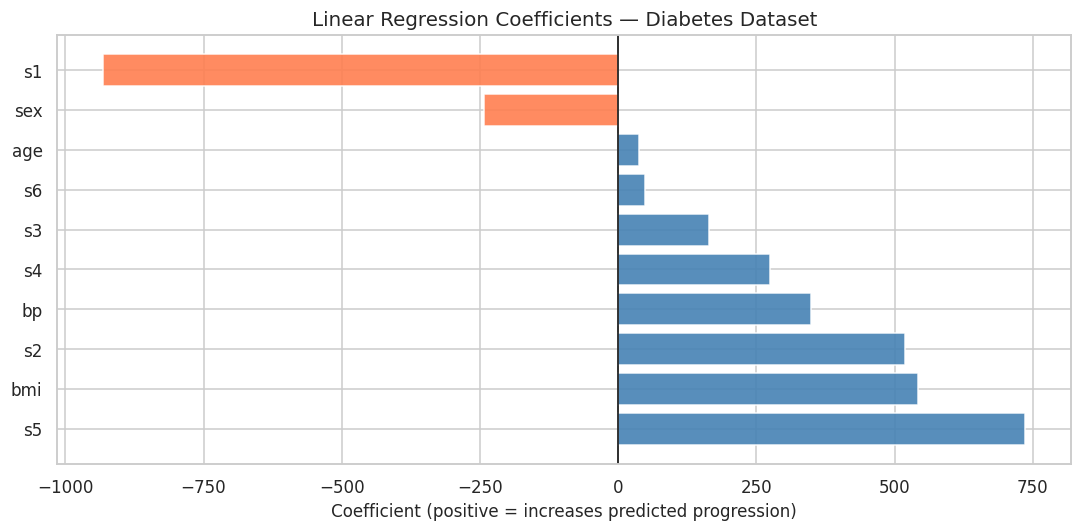

Largest positive coefficient: s5 (736.199)
Largest negative coefficient: s1 (-931.489)


In [16]:
# ── 7.3  Coefficient plot — which features matter most? ──────────────

coef_df = pd.DataFrame({
    "feature":     X_diab.columns,
    "coefficient": lr.coef_
}).sort_values("coefficient", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["steelblue" if c > 0 else "coral" for c in coef_df["coefficient"]]
ax.barh(coef_df["feature"], coef_df["coefficient"],
        color=colors, edgecolor="white", alpha=0.9)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Linear Regression Coefficients — Diabetes Dataset")
ax.set_xlabel("Coefficient (positive = increases predicted progression)")
plt.tight_layout(); plt.show()

print(f"Largest positive coefficient: {coef_df.iloc[0]['feature']} ({coef_df.iloc[0]['coefficient']:.3f})")
print(f"Largest negative coefficient: {coef_df.iloc[-1]['feature']} ({coef_df.iloc[-1]['coefficient']:.3f})")

## Part 8 — Regularization: Ridge, Lasso, and ElasticNet

In [17]:
# ── 8.1  Why regularization? ─────────────────────────────────────────
# Plain linear regression: minimise MSE only.
# Regularized regression adds a penalty on the size of coefficients:
#
#   Ridge (L2):   MSE + alpha * sum(beta_j^2)
#                 → shrinks all coefficients; keeps all features; no exact zeros
#
#   Lasso (L1):   MSE + alpha * sum(|beta_j|)
#                 → shrinks AND zeros out coefficients; performs automatic feature selection
#
#   ElasticNet:   MSE + alpha * [l1_ratio * sum(|beta_j|) + (1-l1_ratio) * sum(beta_j^2)]
#                 → mixture of Ridge and Lasso
#
# alpha = 0  →  plain ordinary least squares (no regularization)
# large alpha → strong shrinkage toward zero
#
# We use the synthetic dataset (20 features, only 10 truly informative)
# to illustrate how Lasso discovers which features to keep.

X_r_train, X_r_test, y_r_train, y_r_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

sc_reg       = StandardScaler()
X_r_train_sc = sc_reg.fit_transform(X_r_train)
X_r_test_sc  = sc_reg.transform(X_r_test)

models = {
    "Linear (no reg)": LinearRegression(),
    "Ridge (alpha=1)":    Ridge(alpha=1.0),
    "Ridge (alpha=100)":  Ridge(alpha=100.0),
    "Lasso (alpha=1)":    Lasso(alpha=1.0,  max_iter=10000),
    "Lasso (alpha=10)":   Lasso(alpha=10.0, max_iter=10000),
    "ElasticNet":         ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=10000),
}

reg_results = {}
for name, model in models.items():
    model.fit(X_r_train_sc, y_r_train)
    y_hat = model.predict(X_r_test_sc)
    reg_results[name] = {
        "r2":   r2_score(y_r_test, y_hat),
        "rmse": np.sqrt(mean_squared_error(y_r_test, y_hat)),
        "coef": model.coef_
    }
    n_zero = np.sum(np.abs(model.coef_) < 1e-4)
    print(f"{name:22s}  R²={reg_results[name]['r2']:.4f}  RMSE={reg_results[name]['rmse']:.2f}  zero coefs={n_zero}")

Linear (no reg)         R²=0.9664  RMSE=26.09  zero coefs=0
Ridge (alpha=1)         R²=0.9658  RMSE=26.33  zero coefs=0
Ridge (alpha=100)       R²=0.8369  RMSE=57.47  zero coefs=0
Lasso (alpha=1)         R²=0.9655  RMSE=26.42  zero coefs=5
Lasso (alpha=10)        R²=0.9152  RMSE=41.44  zero coefs=10
ElasticNet              R²=0.8060  RMSE=62.68  zero coefs=1


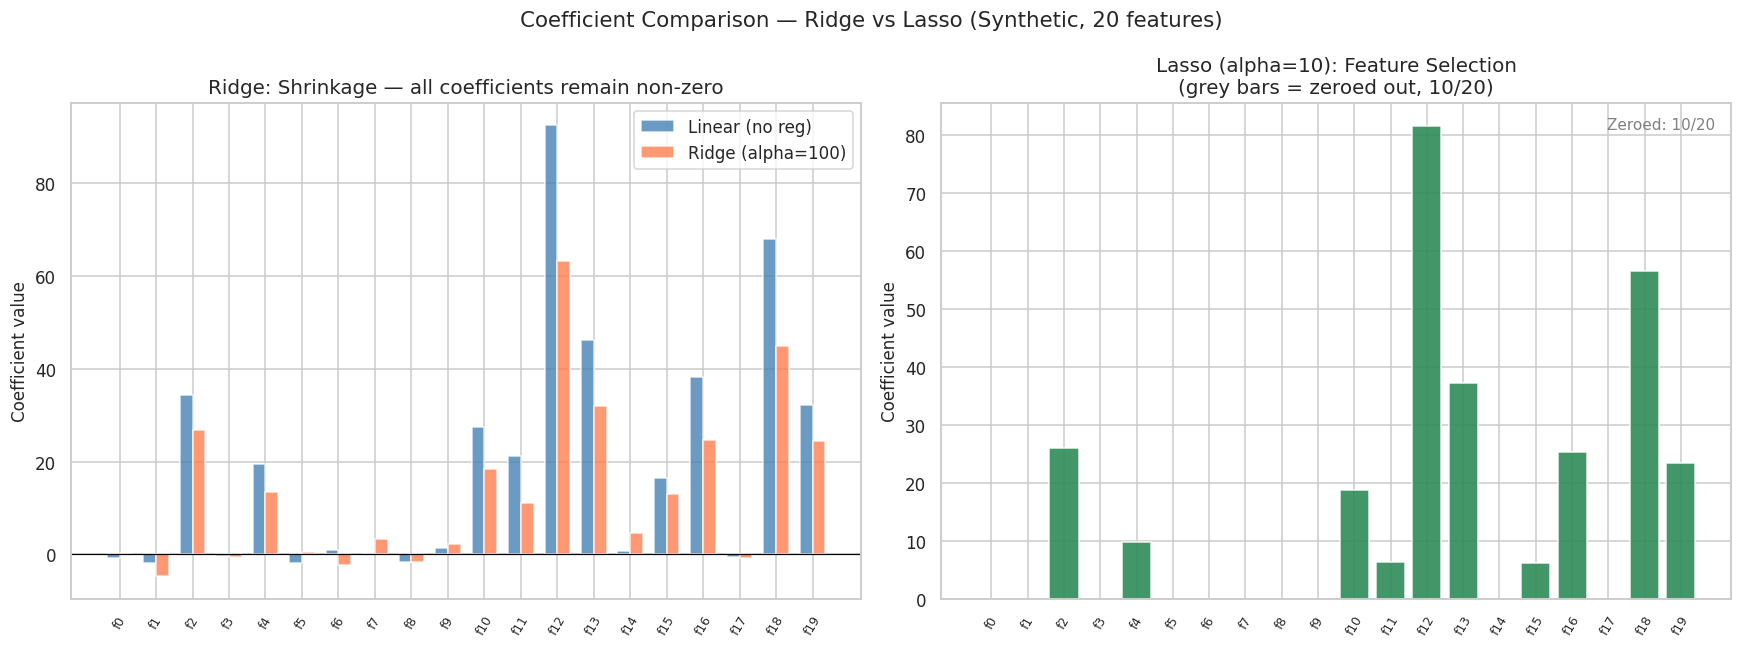

Ridge: shrinks all coefficients but never reaches exactly zero.
Lasso: drives uninformative coefficients to exactly zero = automatic feature selection.


In [18]:
# ── 8.2  Coefficient paths: Ridge shrinks, Lasso zeros ───────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Coefficient Comparison — Ridge vs Lasso (Synthetic, 20 features)", fontsize=14)

x = np.arange(20)
feature_labels = [f"f{i}" for i in range(20)]
width = 0.35

ax = axes[0]
ax.bar(x - width/2, reg_results["Linear (no reg)"]["coef"], width,
       label="Linear (no reg)", color="steelblue", alpha=0.8, edgecolor="white")
ax.bar(x + width/2, reg_results["Ridge (alpha=100)"]["coef"],   width,
       label="Ridge (alpha=100)", color="coral", alpha=0.8, edgecolor="white")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(feature_labels, rotation=60, fontsize=8)
ax.set_title("Ridge: Shrinkage — all coefficients remain non-zero")
ax.set_ylabel("Coefficient value"); ax.legend()

ax = axes[1]
lasso_coef = reg_results["Lasso (alpha=10)"]["coef"]
colors_l   = ["seagreen" if abs(c) > 0.01 else "lightgrey" for c in lasso_coef]
ax.bar(x, lasso_coef, color=colors_l, edgecolor="white", alpha=0.9)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(feature_labels, rotation=60, fontsize=8)
n_zero = np.sum(np.abs(lasso_coef) < 0.01)
ax.set_title(f"Lasso (alpha=10): Feature Selection\n(grey bars = zeroed out, {n_zero}/20)")
ax.set_ylabel("Coefficient value")
ax.text(0.98, 0.97, f"Zeroed: {n_zero}/20",
        transform=ax.transAxes, ha="right", va="top", fontsize=10, color="grey")

plt.tight_layout(); plt.show()

print("Ridge: shrinks all coefficients but never reaches exactly zero.")
print("Lasso: drives uninformative coefficients to exactly zero = automatic feature selection.")

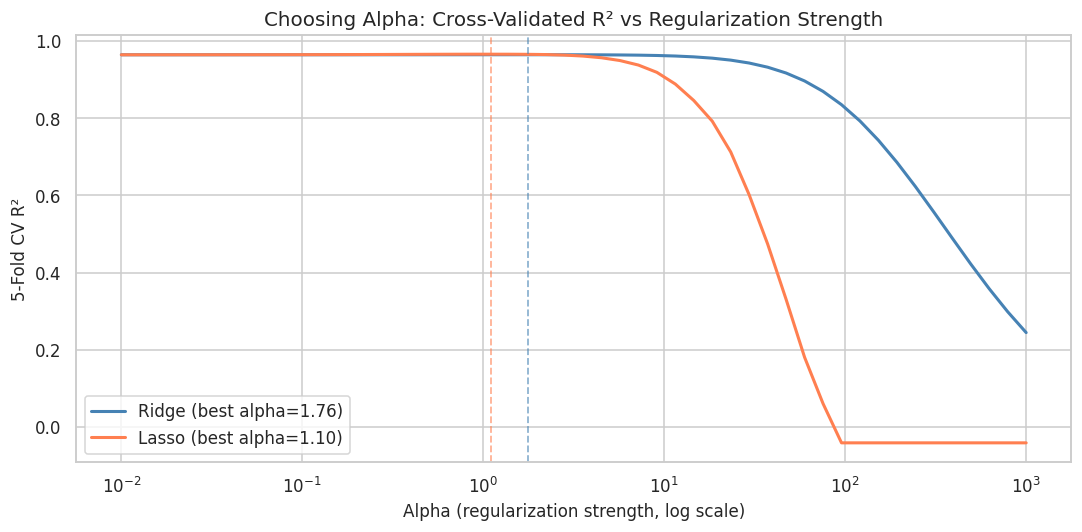

Best alpha — Ridge: 1.7575  |  Lasso: 1.0985
CV R²     — Ridge: 0.9644  |  Lasso: 0.9658


In [19]:
# ── 8.3  Tuning alpha with cross-validation ───────────────────────────
# Scan a grid of alpha values. For each, run 5-fold CV and record the mean R².
# The alpha that maximises CV R² is the best choice.

alpha_range     = np.logspace(-2, 3, 50)
cv_r2_ridge     = []
cv_r2_lasso     = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for alpha in alpha_range:
    ridge = Pipeline([("sc", StandardScaler()), ("m", Ridge(alpha=alpha))])
    lasso = Pipeline([("sc", StandardScaler()), ("m", Lasso(alpha=alpha, max_iter=10000))])
    cv_r2_ridge.append(cross_val_score(ridge, X_r_train, y_r_train, cv=kf, scoring="r2").mean())
    cv_r2_lasso.append(cross_val_score(lasso, X_r_train, y_r_train, cv=kf, scoring="r2").mean())

best_alpha_ridge = alpha_range[np.argmax(cv_r2_ridge)]
best_alpha_lasso = alpha_range[np.argmax(cv_r2_lasso)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(alpha_range, cv_r2_ridge, label=f"Ridge (best alpha={best_alpha_ridge:.2f})",
            color="steelblue", linewidth=2)
ax.semilogx(alpha_range, cv_r2_lasso, label=f"Lasso (best alpha={best_alpha_lasso:.2f})",
            color="coral", linewidth=2)
ax.axvline(best_alpha_ridge, color="steelblue", linestyle="--", linewidth=1.2, alpha=0.6)
ax.axvline(best_alpha_lasso, color="coral",     linestyle="--", linewidth=1.2, alpha=0.6)
ax.set_xlabel("Alpha (regularization strength, log scale)")
ax.set_ylabel("5-Fold CV R²")
ax.set_title("Choosing Alpha: Cross-Validated R² vs Regularization Strength")
ax.legend()
plt.tight_layout(); plt.show()

print(f"Best alpha — Ridge: {best_alpha_ridge:.4f}  |  Lasso: {best_alpha_lasso:.4f}")
print(f"CV R²     — Ridge: {max(cv_r2_ridge):.4f}  |  Lasso: {max(cv_r2_lasso):.4f}")

## Part 9 — Regression Summary Dashboard

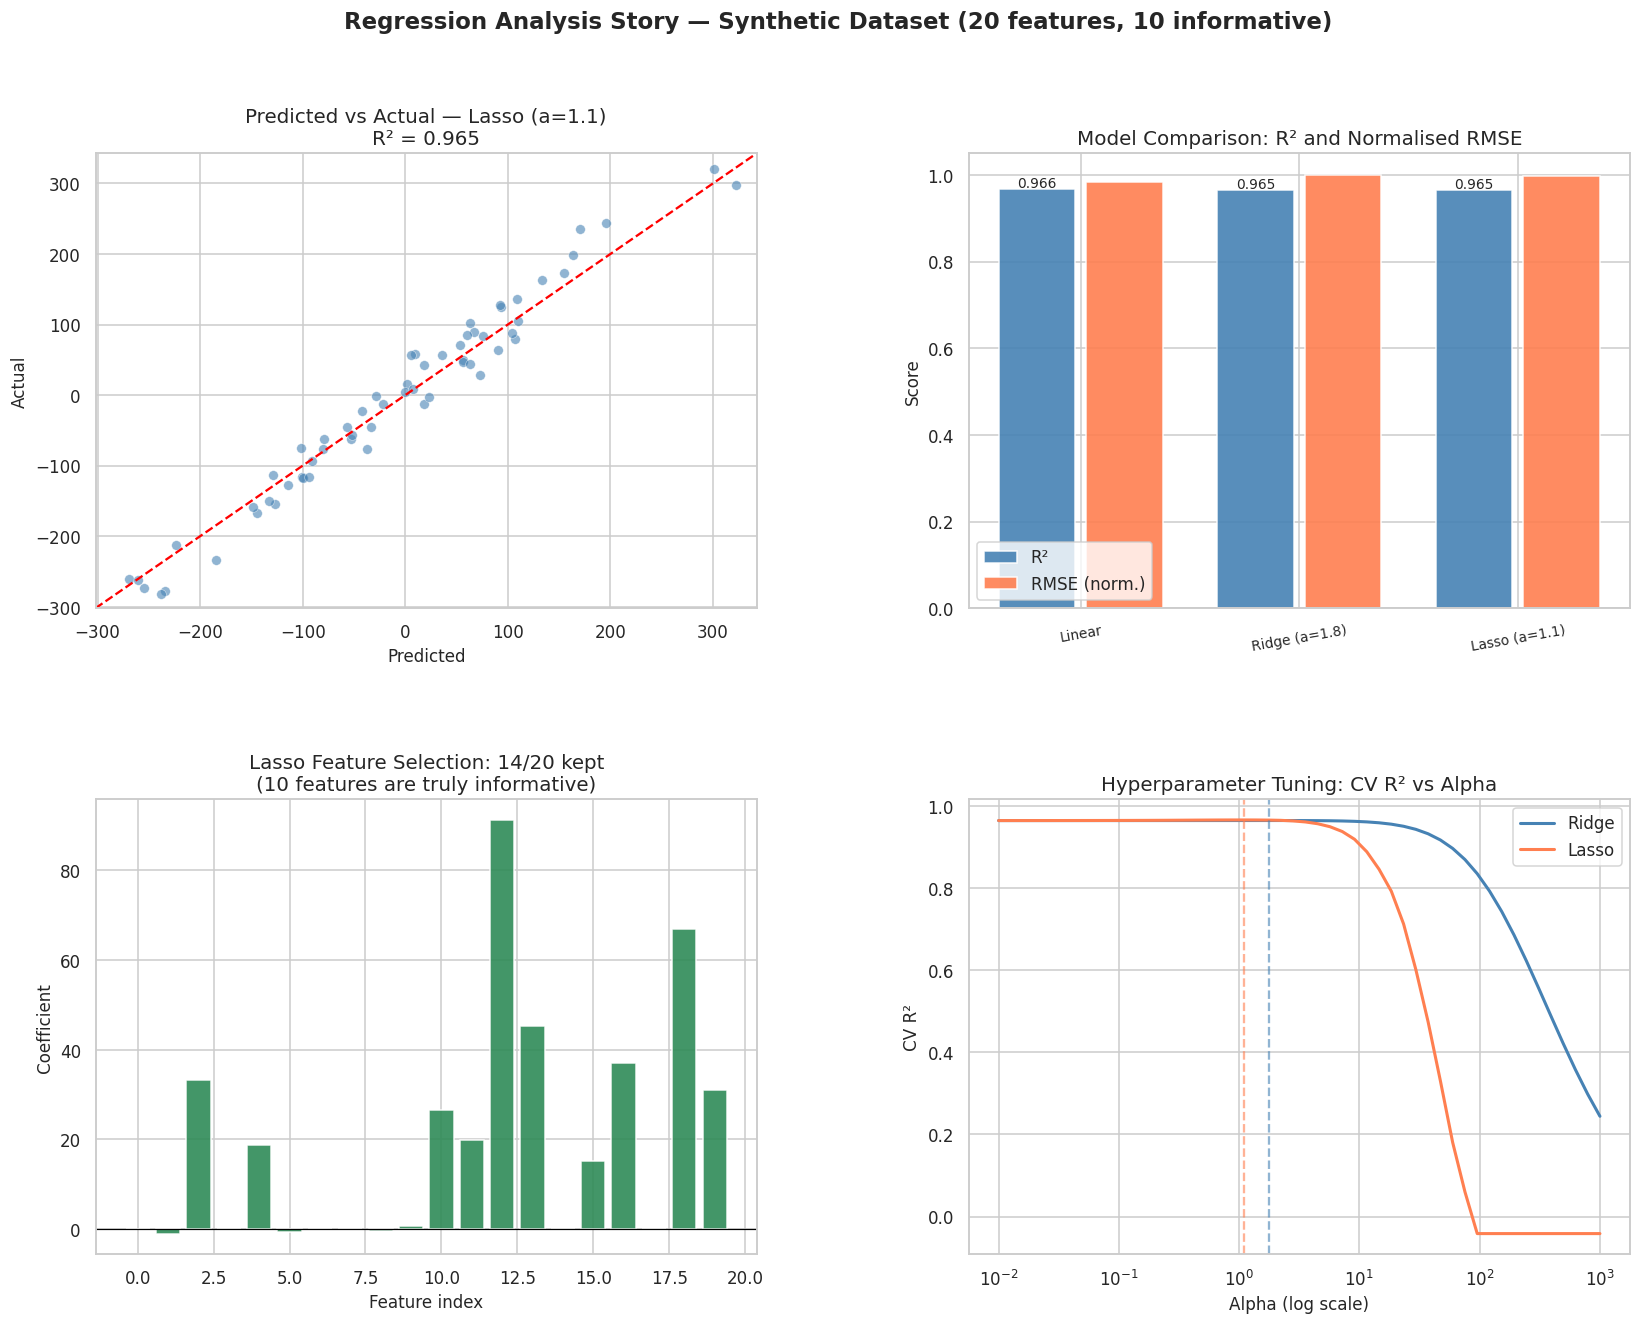

Dashboard saved as regression_dashboard.png


In [20]:
# ── 9.1  Four-panel regression story ─────────────────────────────────

final_lr    = LinearRegression()
final_ridge = Ridge(alpha=best_alpha_ridge)
final_lasso = Lasso(alpha=best_alpha_lasso, max_iter=10000)

for m in [final_lr, final_ridge, final_lasso]:
    m.fit(X_r_train_sc, y_r_train)

final_preds = {
    "Linear":                      final_lr.predict(X_r_test_sc),
    f"Ridge (a={best_alpha_ridge:.1f})": final_ridge.predict(X_r_test_sc),
    f"Lasso (a={best_alpha_lasso:.1f})": final_lasso.predict(X_r_test_sc),
}
final_r2   = {k: r2_score(y_r_test, v)                         for k, v in final_preds.items()}
final_rmse = {k: np.sqrt(mean_squared_error(y_r_test, v))      for k, v in final_preds.items()}

fig = plt.figure(figsize=(18, 13))
fig.suptitle("Regression Analysis Story — Synthetic Dataset (20 features, 10 informative)",
             fontsize=15, fontweight="bold")
gs = gridspec.GridSpec(2, 2, hspace=0.42, wspace=0.32)

# Panel 1: Predicted vs Actual (Lasso)
ax1 = fig.add_subplot(gs[0, 0])
lasso_key = f"Lasso (a={best_alpha_lasso:.1f})"
y_hat_best = final_preds[lasso_key]
ax1.scatter(y_hat_best, y_r_test, alpha=0.6, color="steelblue",
            edgecolors="white", linewidth=0.4, s=40)
lim = (min(y_r_test.min(), y_hat_best.min()) - 20,
       max(y_r_test.max(), y_hat_best.max()) + 20)
ax1.plot(lim, lim, "--", color="red", linewidth=1.5)
ax1.set_xlim(lim); ax1.set_ylim(lim)
ax1.set_xlabel("Predicted"); ax1.set_ylabel("Actual")
ax1.set_title(f"Predicted vs Actual — {lasso_key}\nR² = {final_r2[lasso_key]:.3f}")

# Panel 2: Model comparison
ax2 = fig.add_subplot(gs[0, 1])
model_names = list(final_r2.keys())
r2_vals     = [final_r2[k] for k in model_names]
rmse_norm   = [final_rmse[k] / max(final_rmse.values()) for k in model_names]
x = np.arange(len(model_names))
b1 = ax2.bar(x - 0.2, r2_vals,   0.35, label="R²",           color="steelblue", edgecolor="white", alpha=0.9)
b2 = ax2.bar(x + 0.2, rmse_norm, 0.35, label="RMSE (norm.)", color="coral",     edgecolor="white", alpha=0.9)
ax2.set_xticks(x); ax2.set_xticklabels(model_names, rotation=10, fontsize=9)
ax2.set_ylabel("Score"); ax2.set_title("Model Comparison: R² and Normalised RMSE")
ax2.legend()
for bar, v in zip(b1, r2_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{v:.3f}", ha="center", fontsize=9)

# Panel 3: Lasso coefficients
ax3 = fig.add_subplot(gs[1, 0])
coef_lasso = final_lasso.coef_
colors_l   = ["seagreen" if abs(c) > 0.01 else "lightgrey" for c in coef_lasso]
ax3.bar(range(20), coef_lasso, color=colors_l, edgecolor="white", alpha=0.9)
ax3.axhline(0, color="black", linewidth=0.8)
ax3.set_xlabel("Feature index"); ax3.set_ylabel("Coefficient")
n_nonzero = np.sum(np.abs(coef_lasso) > 0.01)
ax3.set_title(f"Lasso Feature Selection: {n_nonzero}/20 kept\n(10 features are truly informative)")

# Panel 4: Alpha tuning
ax4 = fig.add_subplot(gs[1, 1])
ax4.semilogx(alpha_range, cv_r2_ridge, label="Ridge", color="steelblue", linewidth=2)
ax4.semilogx(alpha_range, cv_r2_lasso, label="Lasso", color="coral",     linewidth=2)
ax4.axvline(best_alpha_ridge, color="steelblue", linestyle="--", alpha=0.6)
ax4.axvline(best_alpha_lasso, color="coral",     linestyle="--", alpha=0.6)
ax4.set_xlabel("Alpha (log scale)"); ax4.set_ylabel("CV R²")
ax4.set_title("Hyperparameter Tuning: CV R² vs Alpha"); ax4.legend()

plt.tight_layout()
plt.savefig("regression_dashboard.png", dpi=110, bbox_inches="tight")
plt.show()
print("Dashboard saved as regression_dashboard.png")

### Exercise 3 — Full Regression Workflow (Week 11)

Using the **Diabetes dataset** (`X_diab`, `y_diab`):

1. Split 80% train / 20% test (`random_state=42`). Scale with `StandardScaler`.
2. Train **Linear Regression**, **Ridge**, and **Lasso**. Report MSE, RMSE, MAE, and R² on the test set for each.
3. Perform **cross-validated alpha search** over `np.logspace(-2, 3, 50)` for both Ridge and Lasso. Plot the CV R² curve for both on the same axis. What are the best alphas?
4. Train a final **ElasticNet** with `l1_ratio=0.5` and the best Lasso alpha. How does it compare to Ridge and Lasso?
5. Plot **Predicted vs Actual** for all four final models in a 2×2 grid.
6. For Lasso with the best alpha: how many of the 10 features are zeroed out? Which features survive?
7. In a text cell: what does **overfitting** look like in a residual plot, and why does regularization help?

In [ ]:
# Your code here


```
# Your answer here
```

---
## Summary — Upcoming Weeks

### Clustering

| Concept | What it does | Key tools |
|---|---|---|
| **K-Means** | Partition into k spherical clusters | `KMeans` |
| **Elbow method** | Inertia vs k — find the kink | `KMeans.inertia_` |
| **Silhouette score** | Quality metric without labels | `silhouette_score` |
| **DBSCAN** | Density-based; arbitrary shapes; detects noise | `DBSCAN` |

**When to use what:**
- K-Means: compact, roughly spherical clusters; k discoverable from elbow/silhouette
- DBSCAN: irregular shapes, noisy data, k unknown in advance

---

### Classification

| Concept | Meaning | Key tools |
|---|---|---|
| **Train/Test split** | Hold-out set evaluated only once | `train_test_split` |
| **Accuracy** | (TP + TN) / total | `accuracy_score` |
| **Precision** | TP / (TP + FP) | `precision_score` |
| **Recall** | TP / (TP + FN) | `recall_score` |
| **F1-Score** | Harmonic mean of Precision & Recall | `f1_score` |
| **ROC-AUC** | Threshold-free ranking quality | `roc_auc_score` |
| **Cross-validation** | Model selection without leakage | `cross_val_score` |

**Choose the right metric:** Recall when FN is dangerous (cancer); Precision when FP is costly (spam); F1 for balance; AUC for imbalanced or ranking tasks.

---

### Regression & Regularization

| Concept | What it does | Key tools |
|---|---|---|
| **Linear Regression** | Minimise MSE; no constraint on coefficients | `LinearRegression` |
| **RMSE / MAE / R²** | Regression error metrics | `mean_squared_error`, `r2_score` |
| **Ridge (L2)** | Shrinks coefficients; keeps all features | `Ridge` |
| **Lasso (L1)** | Shrinks + zeros coefficients = feature selection | `Lasso` |
| **ElasticNet** | Mixture of L1 and L2 | `ElasticNet` |
| **Alpha tuning** | CV search for optimal regularization | `cross_val_score` loop |

**The regularization decision:**
- **Ridge**: most features are relevant; suffering from multicollinearity
- **Lasso**: many features are irrelevant; want automatic selection
- **ElasticNet**: when you want the best of both

Always tune alpha with cross-validation on the training set, never on the test set.

---

**The complete ML workflow:**

```
Raw data → EDA → Preprocess → Train/Test Split
                                    ↓
                     CV model selection (training set only)
                                    ↓
                     Tune hyperparameters (CV, still training only)
                                    ↓
                     Final test-set evaluation — once!
                                    ↓
                     Interpretation (residuals, confusion matrix, coefficients)
```